100%|██████████| 26.4M/26.4M [00:01<00:00, 20.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]



=== MEMULAI TRAINING UNTUK LATENT DIMENSION: 2 ===
Dim [2] - Epoch [1/10], Loss: 0.1326
Dim [2] - Epoch [2/10], Loss: 0.1127
Dim [2] - Epoch [3/10], Loss: 0.1081
Dim [2] - Epoch [4/10], Loss: 0.1059
Dim [2] - Epoch [5/10], Loss: 0.1042
Dim [2] - Epoch [6/10], Loss: 0.1028
Dim [2] - Epoch [7/10], Loss: 0.1014
Dim [2] - Epoch [8/10], Loss: 0.1009
Dim [2] - Epoch [9/10], Loss: 0.1000
Dim [2] - Epoch [10/10], Loss: 0.0987


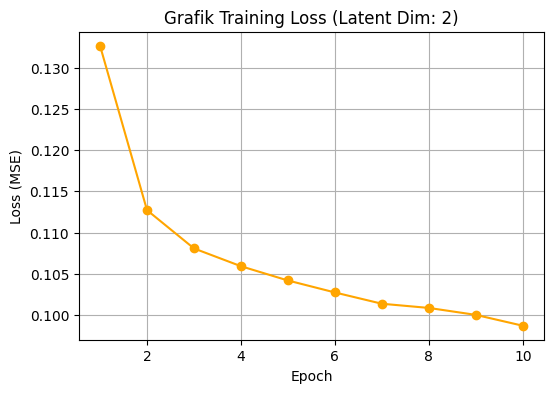

Model untuk Dimensi 2 BERHASIL DISIMPAN!

=== MEMULAI TRAINING UNTUK LATENT DIMENSION: 8 ===
Dim [8] - Epoch [1/10], Loss: 0.0896
Dim [8] - Epoch [2/10], Loss: 0.0619
Dim [8] - Epoch [3/10], Loss: 0.0577
Dim [8] - Epoch [4/10], Loss: 0.0554
Dim [8] - Epoch [5/10], Loss: 0.0540
Dim [8] - Epoch [6/10], Loss: 0.0530
Dim [8] - Epoch [7/10], Loss: 0.0521
Dim [8] - Epoch [8/10], Loss: 0.0514
Dim [8] - Epoch [9/10], Loss: 0.0508
Dim [8] - Epoch [10/10], Loss: 0.0503


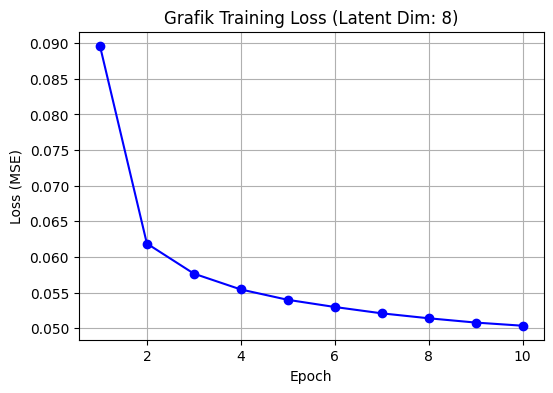

Model untuk Dimensi 8 BERHASIL DISIMPAN!

=== MEMULAI TRAINING UNTUK LATENT DIMENSION: 32 ===
Dim [32] - Epoch [1/10], Loss: 0.0850
Dim [32] - Epoch [2/10], Loss: 0.0527
Dim [32] - Epoch [3/10], Loss: 0.0456
Dim [32] - Epoch [4/10], Loss: 0.0419
Dim [32] - Epoch [5/10], Loss: 0.0395
Dim [32] - Epoch [6/10], Loss: 0.0378
Dim [32] - Epoch [7/10], Loss: 0.0366
Dim [32] - Epoch [8/10], Loss: 0.0354
Dim [32] - Epoch [9/10], Loss: 0.0346
Dim [32] - Epoch [10/10], Loss: 0.0338


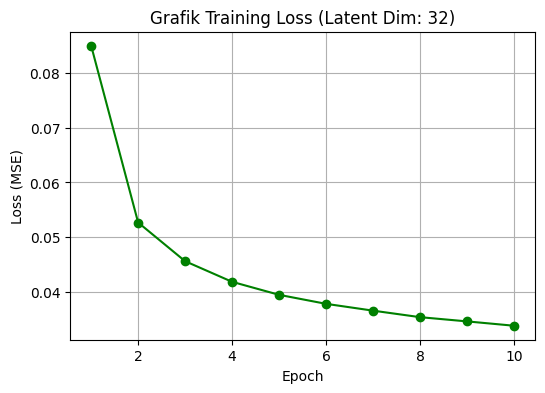

Model untuk Dimensi 32 BERHASIL DISIMPAN!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# 1. Pengaturan Device (Menggunakan GPU jika aktif)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10  # 10 Epoch sudah cukup untuk melihat penurunan loss yang stabil

# 2. Download dan Siapkan Dataset Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# 3. Arsitektur Autoencoder
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
    def forward(self, x):
        return self.linear(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.linear = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.linear(x)
        return x.view(-1, 1, 28, 28)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# 4. Loop Eksperimen untuk Dimensi Latent: 2, 8, dan 32
latent_dimensions = [2, 8, 32]

for idx, latent_dim in enumerate(latent_dimensions):
    print(f"\n=== MEMULAI TRAINING UNTUK LATENT DIMENSION: {latent_dim} ===")
    
    model = Autoencoder(latent_dim).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    loss_history = []
    
    # Proses Training
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        loss_history.append(epoch_loss)
        print(f"Dim [{latent_dim}] - Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.4f}")
    
    # Plot Grafik Loss untuk Laporan
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, EPOCHS+1), loss_history, marker='o', color='orange' if latent_dim==2 else 'blue' if latent_dim==8 else 'green')
    plt.title(f'Grafik Training Loss (Latent Dim: {latent_dim})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.show()
    
    # Menyimpan Model Lengkap dan Decoder Terpisah
    torch.save(model.state_dict(), f"autoencoder_dim{latent_dim}.pth")
    torch.save(model.decoder.state_dict(), f"decoder_dim{latent_dim}.pth")
    print(f"Model untuk Dimensi {latent_dim} BERHASIL DISIMPAN!")